In [32]:
# =========================
# IMPORT LIBRARIES
# =========================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np

In [33]:
# =========================
# CHECK TABLE NAMES
# =========================

conn = sqlite3.connect(r"C:\Users\sweth\Desktop\Y3S1\AI Solutions Development\Project\SD_project\data\gas_monitoring.db")

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

conn.close()

print("Tables found in database:")
print(tables)

Tables found in database:
             name
0  gas_monitoring


In [34]:
# =========================
# CHECK CURRENT FOLDER AND DATABASE FILE
# =========================

# print("Current working directory:")
# print(os.getcwd())

# print("\nFiles in data folder:")
# data_dir = os.path.join(os.getcwd(), "data")

# if os.path.isdir(data_dir):
#     print(os.listdir(data_dir))
# else:
#     print(f"'data' folder not found at: {data_dir}")

# db_path = r"C:\Users\sweth\Desktop\Y3S1\AI Solutions Development\Project\SD_project\data\gas_monitoring.db"

# print("\nDoes database exist?")
# print(os.path.exists(db_path))

# print("\nDatabase file size in bytes:")
# print(os.path.getsize(db_path))

In [35]:
# =========================
# LOAD DATABASE AUTOMATICALLY
# =========================

conn = sqlite3.connect(r"C:\Users\sweth\Desktop\Y3S1\AI Solutions Development\Project\SD_project\data\gas_monitoring.db")

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Tables found:")
print(tables)

table_name = tables.iloc[0, 0]

df = pd.read_sql_query(f'SELECT * FROM "{table_name}"', conn)

conn.close()

print("\nUsing table:", table_name)
print("\nDataset loaded successfully.")
print(df.head())
print(df.shape)

Tables found:
             name
0  gas_monitoring

Using table: gas_monitoring

Dataset loaded successfully.
  Time of Day  Temperature  Humidity  CO2_InfraredSensor  \
0     morning        19.63     53.83          125.486389   
1     morning       292.81     53.69          126.343018   
2     morning        19.62     54.25          126.560695   
3     morning        20.10     50.48          113.504877   
4     morning        19.89     48.42           92.766225   

   CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  \
0                 571.089440              478.554958              735.850412   
1                 575.789501              491.955151              740.282738   
2                 585.543111              505.560808              737.112906   
3                 597.449961              515.142272              744.020651   
4                 613.654875              535.664558              770.265441   

   MetalOxideSensor_Unit3  MetalOxideSensor_Unit4

In [36]:
# =========================
# CONNECT TO DATABASE IN VS CODE
# =========================

import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\sweth\Desktop\Y3S1\AI Solutions Development\Project\SD_project\data\gas_monitoring.db")

df = pd.read_sql_query("SELECT * FROM gas_monitoring", conn)

conn.close()

print("Dataset loaded successfully.")
print(df.head())
print(df.shape)

Dataset loaded successfully.
  Time of Day  Temperature  Humidity  CO2_InfraredSensor  \
0     morning        19.63     53.83          125.486389   
1     morning       292.81     53.69          126.343018   
2     morning        19.62     54.25          126.560695   
3     morning        20.10     50.48          113.504877   
4     morning        19.89     48.42           92.766225   

   CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  \
0                 571.089440              478.554958              735.850412   
1                 575.789501              491.955151              740.282738   
2                 585.543111              505.560808              737.112906   
3                 597.449961              515.142272              744.020651   
4                 613.654875              535.664558              770.265441   

   MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor  Session ID  \
0              654.625253              565.051969 

In [37]:
df

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,NaN,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,evening,23.45,NaN,137.854649,544.124855,510.926349,NaN,680.916215,620.292682,1.0,2586,maintenance_mode,very_bright,Low Activity
9996,evening,297.24,46.98,131.945968,541.756022,517.719693,738.901193,689.383365,625.100827,2.0,2586,ventilation_only,very_dim,Low Activity
9997,evening,23.71,49.16,136.422868,542.072190,512.607291,732.456099,683.197988,622.035384,2.0,2586,eco_mode,very_bright,Low Activity
9998,night,20.58,NaN,126.734430,561.716292,435.638480,707.447312,648.634308,581.583550,1.0,4761,cooling_active,very_bright,Low Activity


In [38]:
# # =========================
# # CORRELATION MATRIX FOR NUMERICAL COLUMNS
# # =========================

# # Remove SESSION_ID if it exists
# df_corr = df.drop(columns=['Session ID'], errors='ignore')

# # Select only numerical columns
# numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])

# # Create correlation matrix
# corr_matrix = numeric_df.corr()

# # Display correlation matrix
# print("Correlation Matrix:")
# display(corr_matrix)

# # Plot heatmap
# plt.figure(figsize=(12, 8))

# sns.heatmap(
#     corr_matrix,
#     annot=True,
#     cmap="coolwarm",
#     fmt=".2f",
#     linewidths=0.5
# )

# plt.title("Correlation Heatmap of Numerical Variables")
# plt.show()

We removed Session ID eventhough it is a numerical variable as it acts as an identifier and does not contribute to meaningful insights during data analysis.

Insights:
- CO2_ElectroChemicalSensor, MetalOxideSensor_Unit1, MetalOxideSensor_Unit2, MetalOxideSensor_Unit3, MetalOxideSensor_Unit4 have moderate to high correalation to eachother as compared to other columsn in the dataset. 
- We used this correlation matrix as a guide to fill in the null values in the columns. 
- CO_GasSensor has a negative correlation to all the Sensors except for CO2_InfraredSensor, this means that when 


In [8]:
   
# corr = df['CO_GasSensor'].corr(df['CO2_ElectroChemicalSensor'])

# plt.figure(figsize=(10, 6))

# sns.regplot(
#     x='CO_GasSensor',
#     y='CO2_ElectroChemicalSensor',
#     data=df,
#     scatter=False,   # hides dots
#     line_kws={'linewidth': 3}
# )

# plt.title(
#     f'CO Gas Sensor vs CO2 Electrochemical Sensor\nCorrelation = {corr:.4f}'
# )

# plt.xlabel('CO Gas Sensor')
# plt.ylabel('CO2 Electrochemical Sensor')

# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

In [10]:
# corr = df['CO_GasSensor'].corr(df['CO2_InfraredSensor'])

# plt.figure(figsize=(10, 6))

# sns.regplot(
#     x='CO_GasSensor',
#     y='CO2_InfraredSensor',
#     data=df,
#     scatter=False,   # hides dots
#     line_kws={'linewidth': 3}
# )

# plt.title(
#     f'CO Gas Sensor vs CO2 Infrared Sensor\nCorrelation = {corr:.4f}'
# )

# plt.xlabel('CO Gas Sensor')
# plt.ylabel('CO2 Infrared Sensor')

# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

In [39]:
# =========================
# BASIC INFORMATION
# =========================

print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

First 5 Rows:


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,NaN,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity



Dataset Shape:
(10000, 14)

Column Names:
Index(['Time of Day', 'Temperature', 'Humidity', 'CO2_InfraredSensor',
       'CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit1',
       'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3',
       'MetalOxideSensor_Unit4', 'CO_GasSensor', 'Session ID',
       'HVAC Operation Mode', 'Ambient Light Level', 'Activity Level'],
      dtype='str')

Missing Values:
Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64

Duplicate Rows:
171


In [40]:
# =========================
# REMOVE DUPLICATES
# =========================

df = df.drop_duplicates()

print("Duplicates removed.")
print("New shape:", df.shape)

Duplicates removed.
New shape: (9829, 14)


In [41]:
df.shape

(9829, 14)

In [14]:
# missing_rows = df[df.isnull().any(axis=1)]

# missing_rows

In [42]:
# =========================
# REMOVE ROWS WITH TEMPERATURE ABOVE 200
# =========================

print("Rows before removing temperature above 200:")
print(df.shape[0])

# Count rows with temperature above 200
temp_above_200_count = (df["Temperature"] > 200).sum()

print("Number of rows with Temperature above 200:")
print(temp_above_200_count)

# Remove rows where Temperature is above 200
df = df[df["Temperature"] <= 200]

print("Rows after removing temperature above 200:")
print(df.shape[0])

print("Rows removed:")
print(temp_above_200_count)

Rows before removing temperature above 200:
9829
Number of rows with Temperature above 200:
795
Rows after removing temperature above 200:
9034
Rows removed:
795


The reason why we removed the rows above 200 as it is not a realistic temperature value in all temperature measurements such as Celcius, Kelvin, Fahrenhiet so we decided to remove this anomoly as it would affect the ML model performance during training. 

Conversion of fahrenheit to Celcius:

250 Fahrenheit = 121 Celcius (This temperature is too high for a normal room temparature)

250 Kelvin = -23.15 (This temperature is too low for a normal room temparature)

250 Celcius (This temperature is also too high for a normal room temperature)

So we cannot assume that 250+ temparatures are recorded in different measurements apart from Celcius when we convert them to Celcius the temperatures are still not normal room temperature. 

In [16]:
# missing_rows = df[df.isnull().any(axis=1)]

# missing_rows

In [18]:
# # =========================
# # HANDLE MISSING VALUES
# # =========================

# # Numerical columns
# numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# for col in numerical_cols:
#     df[col] = df[col].fillna(df[col].median())

# # Categorical columns
# categorical_cols = df.select_dtypes(include=['object']).columns

# for col in categorical_cols:
#     df[col] = df[col].fillna(df[col].mode()[0])

# print("Missing values handled.")
# print(df.isnull().sum())

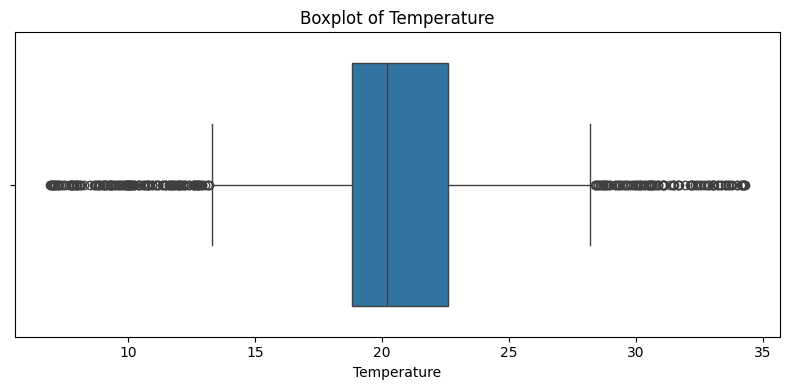

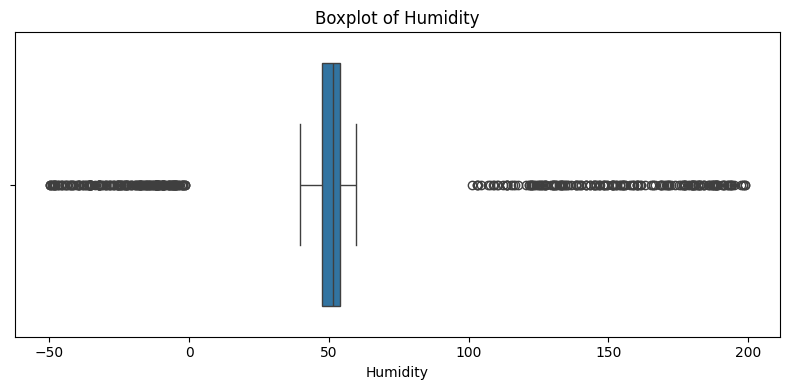

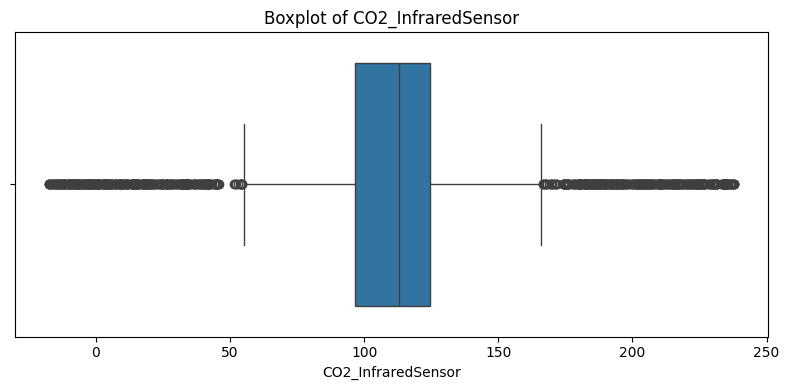

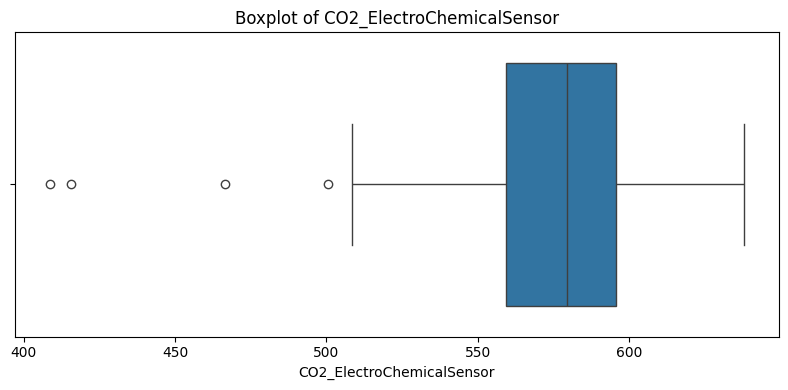

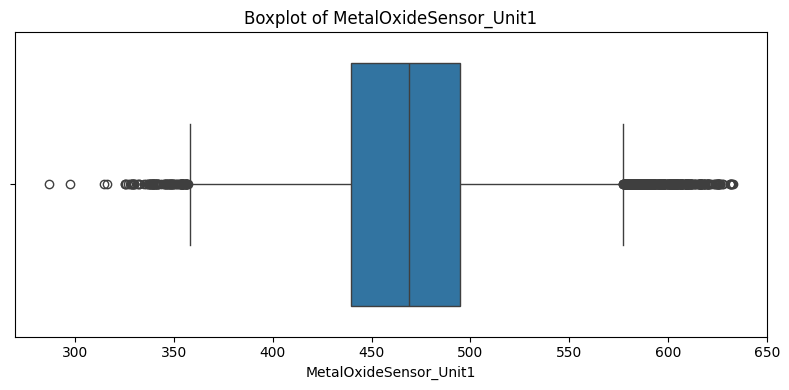

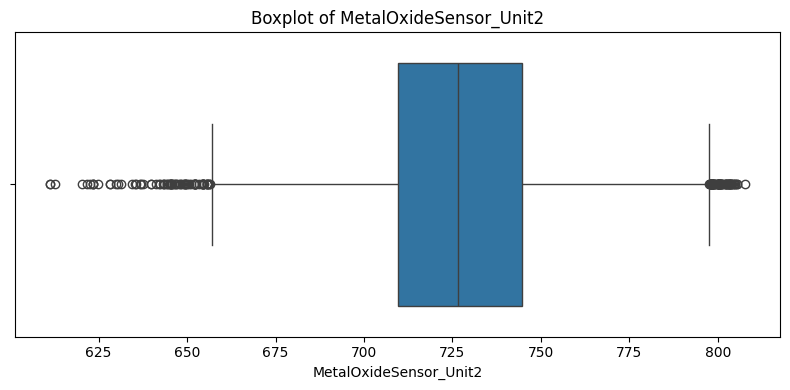

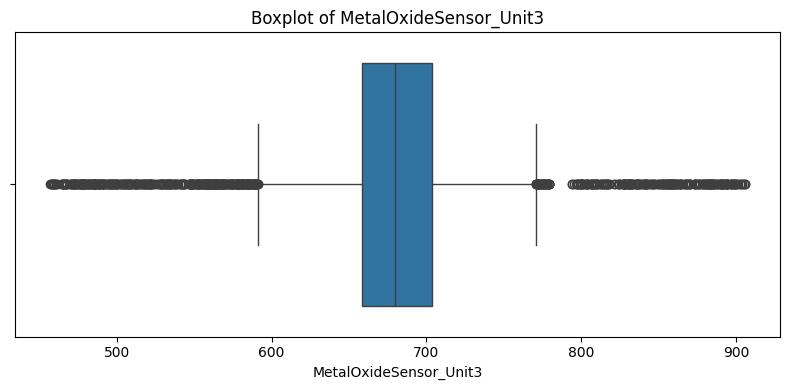

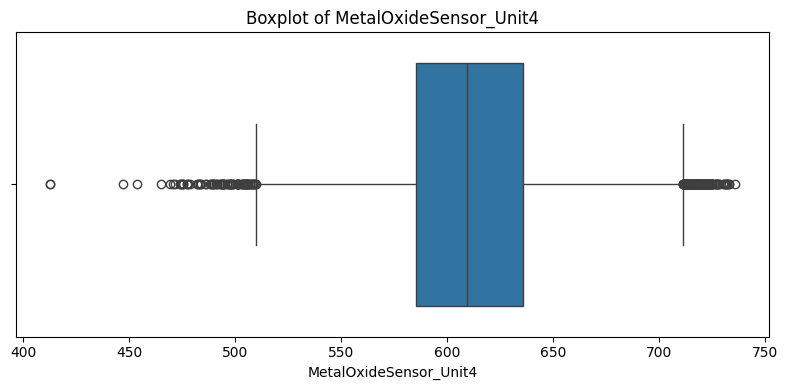

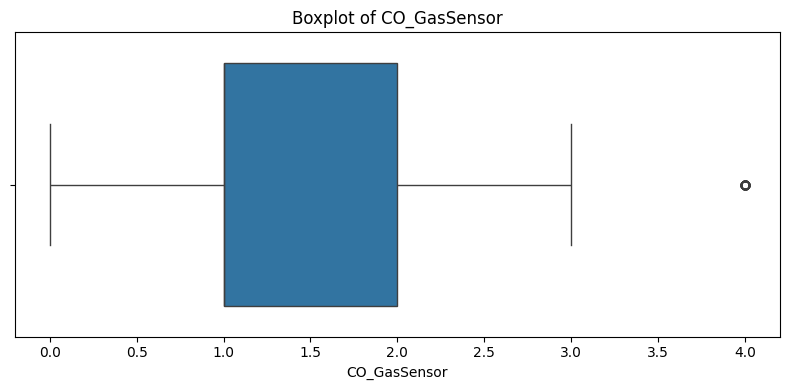

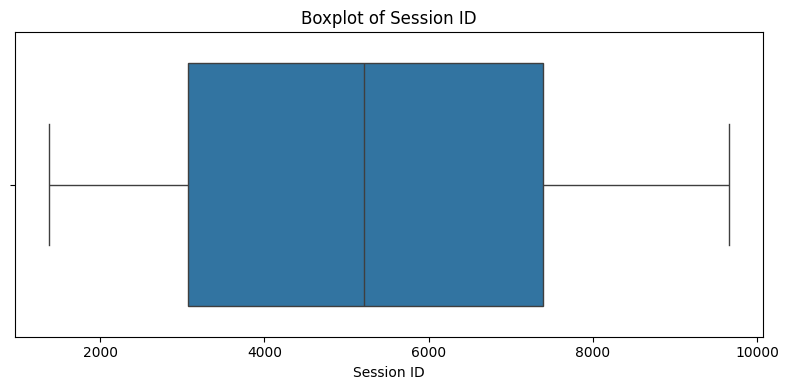

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.drop(columns=['SESSION_ID'], errors='ignore')
numeric_df = numeric_df.select_dtypes(include=['int64', 'float64'])

for col in numeric_df.columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=numeric_df[col])

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

*Analysing Humidity outliers*

In [45]:
df['Humidity'].unique()

array([ 53.83,  54.25,  50.48, ..., -11.6 , -19.31, 152.46], shape=(1992,))

In [46]:
print(df['Humidity'].describe())

count    7273.000000
mean       51.676198
std        21.302474
min       -49.870000
25%        47.700000
50%        51.420000
75%        53.850000
max       198.900000
Name: Humidity, dtype: float64


In [47]:
print(df['Humidity'].min())
print(df['Humidity'].max())

-49.87
198.9


In [48]:
invalid_humidity = df[
    (df['Humidity'] < 0) |
    (df['Humidity'] > 100)
]

print("Number of invalid humidity readings:", len(invalid_humidity))
print(invalid_humidity[['Humidity']])

Number of invalid humidity readings: 375
      Humidity
9       -48.34
50      158.33
120     -14.79
128     135.21
146     -18.73
...        ...
9881    -25.05
9942    183.84
9945    -11.60
9947    -19.31
9983    152.46

[375 rows x 1 columns]


In [49]:
print("Below 0%:")
print((df['Humidity'] < 0).sum())

print("Above 100%:")
print((df['Humidity'] > 100).sum())

Below 0%:
187
Above 100%:
188


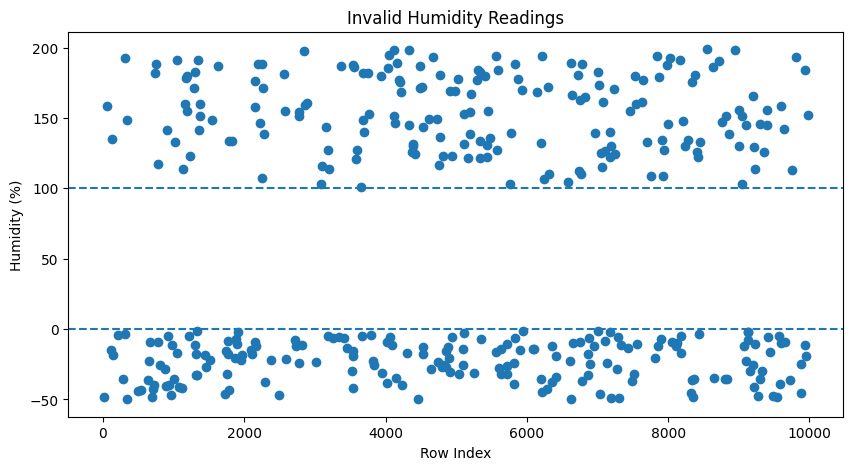

In [50]:
outliers = df[
    (df['Humidity'] < 0) |
    (df['Humidity'] > 100)
]

plt.figure(figsize=(10,5))

plt.scatter(
    outliers.index,
    outliers['Humidity']
)

plt.axhline(0, linestyle='--')
plt.axhline(100, linestyle='--')

plt.title('Invalid Humidity Readings')
plt.xlabel('Row Index')
plt.ylabel('Humidity (%)')

plt.show()

Analysis for Temperature

The analysis for temparature lies before around 13 degrees and after around 28 degrees. Temperatures above 28 is normal in singapore so we are going to keep that those anomolies but remove temperatures below 13 degrees as it does not come under normal room temperature in singapore. If we keep the 13 degrees, it would affect the predictions when training the ML model by giving us unrealisitc outputs such as the room temperature is 8 degrees.


Analysis for Humidity

Majority of the data lies between 47% - 54% relative humidity range. There could be extreme values due to sensor malfunctions, recording errors etc. Around 5.16% of the data are physically impossible to be a measurement of relative humidity. So removing these anomalies would benefit the performance of the ML model.


Analysis for CO2_InfraredSensor

The values are mostly concentrated around 100 to 125. Very low values: around 0 to 50 Very high values: around 170 to 240 This means that the infrared CO2 sensor readings are quite spread out and have many unusual values. We are going to keep the outliers as we are not sure if it is an error.


Analysis for CO2_ElectroChemicalSensor

The values are mostly concentrated around 560 to 600.The few outliers are positioned near the 410 to 505 region. This means the electrochemical CO2 sensor readings are more stable and consistent compared to the infrared sensor. We are going to keep the outliers as we are not sure if it is an error.


Analysis for MetalOxideSensor_Unit1 & MetalOxideSensor_Unit2

keep for both since theres so many outliers that it suggestst it could be natural and not actually an outlier. they are also evenly distributed and not radom spikes

Analysis for MetalOxideSensor_Unit3

Move values are grouped around 650 to 705, 680 being the median. There are many outliers on either side - Low outliers: around 450 to 590 High outliers: around 780 to 900. This meant MetalOxideSensor_Unit3 has a lot of variation and many unusual readings, especially very low and very high values.


Analysis for MetalOxideSensor_Unit4

Most values are grouped around 585 to 635, 610 being the median. There are also outliers on either side - Low outliers: around 415 to 510 High outliers: around 710 to 735. This means MetalOxideSensor_Unit4 is more concentrated than Unit3, but it still has some abnormal readings.


Analysis for CO_GasSensor

Keep the outlier since it is only 1 value above. a value of 4 is dangerous value of CO and could represent something that happened at that point of time like temporary ventilation issue, calibration issue or a appliance or generator emission. with that high value, it is necessary to check on what caused it since it is a safety issue



In [51]:
# =========================
# REMOVE SESSION_ID
# =========================

df = df.drop(columns=['SESSION_ID'], errors='ignore')

# =========================
# REMOVE OUTLIERS FROM HUMIDITY ONLY
# =========================

Q1 = df['Humidity'].quantile(0.25)
Q3 = df['Humidity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only rows within the IQR bounds
df = df[
    (df['Humidity'] >= lower_bound) &
    (df['Humidity'] <= upper_bound)
]

print("Humidity outliers removed using IQR.")
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))
print("New shape:", df.shape)

Humidity outliers removed using IQR.
Lower Bound: 38.48
Upper Bound: 63.08
New shape: (6898, 14)


In [52]:
missing_rows = df[df.isnull().any(axis=1)]

missing_rows

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,NaN,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
11,afternoon,19.71,48.68,80.161332,615.972458,575.491588,780.078308,732.349009,667.927995,0.0,7241,eco_mode,NaN,ModerateActivity
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,NaN,Moderate Activity
17,afternoon,19.73,50.62,91.736107,619.342912,527.869881,761.418621,703.674613,618.386499,0.0,7241,Heating_active,NaN,High Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9966,afternoon,21.78,44.93,77.099437,564.294447,525.204547,758.400140,708.758731,650.528429,1.0,2586,eco_mode,NaN,Moderate Activity
9976,night,20.99,57.61,-9.992761,561.460188,446.620844,703.945003,663.041519,578.163559,1.0,4761,Maintenance_mode,NaN,Low Activity
9977,evening,22.85,46.80,119.371474,586.565204,422.759013,NaN,673.232204,625.357845,2.0,9658,maintenance_mode,very_bright,High Activity
9987,evening,22.61,46.14,90.773122,558.516772,523.640847,739.966424,687.790215,628.766391,NaN,2586,eco_mode,moderate,Low Activity


In [53]:
# =========================
# CHECK RAW CATEGORICAL VALUES
# =========================

print(f"\n'HVAC Operation Mode' raw unique values ({df['HVAC Operation Mode'].nunique()} variants):")
print(sorted(df['HVAC Operation Mode'].unique()), '\n')

print(f"'Activity Level' raw unique values ({df['Activity Level'].nunique()} variants):")
print(sorted(df['Activity Level'].unique()))


'HVAC Operation Mode' raw unique values (23 variants):
['COOLING_ACTIVE', 'Cooling_Active', 'Cooling_active', 'ECO_MODE', 'Eco_Mode', 'Eco_mode', 'HEATING_ACTIVE', 'Heating_Active', 'Heating_active', 'MAINTENANCE_MODE', 'Maintenance_Mode', 'Maintenance_mode', 'OFF', 'Off', 'VENTILATION_ONLY', 'Ventilation_Only', 'Ventilation_only', 'cooling_active', 'eco_mode', 'heating_active', 'maintenance_mode', 'off', 'ventilation_only'] 

'Activity Level' raw unique values (6 variants):
['High Activity', 'Low Activity', 'LowActivity', 'Low_Activity', 'Moderate Activity', 'ModerateActivity']


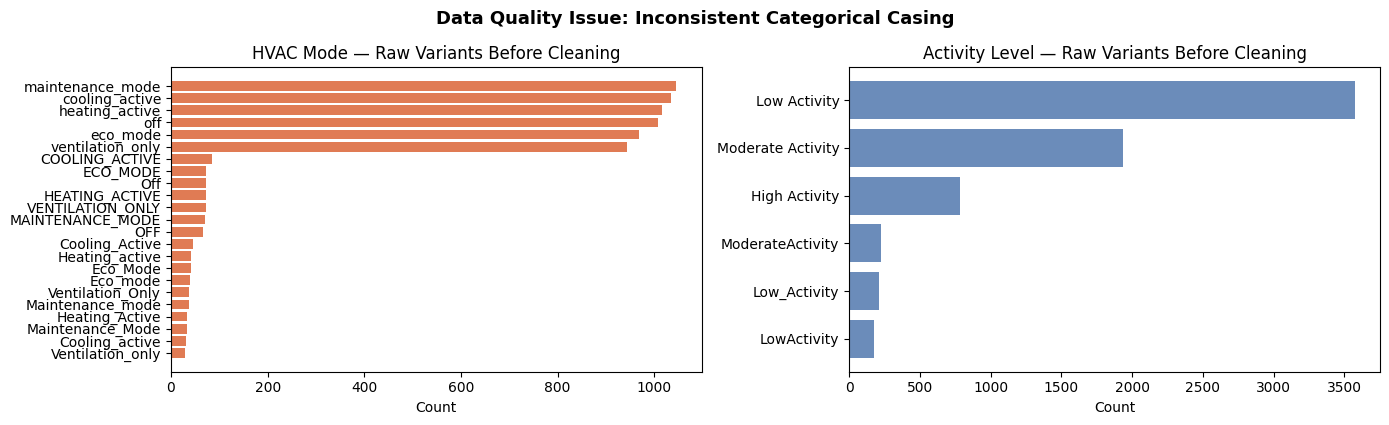


Implication: These must be normalised before group-based analysis.


In [54]:
# =========================
# VISUALISE CATEGORY ISSUES
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# HVAC raw variant counts
hvac_raw = df['HVAC Operation Mode'].value_counts()

axes[0].barh(hvac_raw.index, hvac_raw.values, color='#e07b54')
axes[0].set_title('HVAC Mode — Raw Variants Before Cleaning')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Activity raw variant counts
act_raw = df['Activity Level'].value_counts()

axes[1].barh(act_raw.index, act_raw.values, color='#6b8cba')
axes[1].set_title('Activity Level — Raw Variants Before Cleaning')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()

plt.suptitle(
    'Data Quality Issue: Inconsistent Categorical Casing',
    fontsize=13,
    y=1.05,
    fontweight='bold'
)

plt.show()

print('\nImplication: These must be normalised before group-based analysis.')

cooling_active and COOLING_ACTIVE are the same category but the model will recognise it as different category.This is a case sensitive issue. In order to solve this we need to. We need to normalize these column names into the same format so that it is easier for the model to recognise different categories.

In [55]:
# =========================
# CLEAN CATEGORICAL VALUES
# =========================

df['HVAC Operation Mode'] = (
    df['HVAC Operation Mode']
    .str.strip()
    .str.lower()
)

df['Activity Level'] = (
    df['Activity Level']
    .str.strip()
    .str.lower()
    .str.replace('_', ' ', regex=False)
    .str.replace('lowactivity', 'low activity', regex=False)
    .str.replace('moderateactivity', 'moderate activity', regex=False)
)

print("\nHVAC after cleaning:")
print(sorted(df['HVAC Operation Mode'].unique()))

print("\nActivity after cleaning:")
print(sorted(df['Activity Level'].unique()))


HVAC after cleaning:
['cooling_active', 'eco_mode', 'heating_active', 'maintenance_mode', 'off', 'ventilation_only']

Activity after cleaning:
['high activity', 'low activity', 'moderate activity']


In [56]:
# =========================
# FORMAT ROW VALUES
# =========================
# For rows: lowercase all text values and replace underscores with spaces

text_cols = df.select_dtypes(include=["object", "string"]).columns

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", " ", regex=False)
    )

# Fix specific activity level issues
df["Activity Level"] = (
    df["Activity Level"]
    .str.replace("lowactivity", "low activity", regex=False)
    .str.replace("moderateactivity", "moderate activity", regex=False)
    .str.replace("highactivity", "high activity", regex=False)
)

print("Text row values formatted.")

Text row values formatted.


In [57]:
# =========================
# FINAL CHECK
# =========================

print("\nCleaned Dataset Shape:")
print(df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nRemaining Duplicate Rows:")
print(df.duplicated().sum())


Cleaned Dataset Shape:
(6898, 14)

Remaining Missing Values:
Time of Day                    0
Temperature                    0
Humidity                       0
CO2_InfraredSensor             0
CO2_ElectroChemicalSensor      0
MetalOxideSensor_Unit1         0
MetalOxideSensor_Unit2       981
MetalOxideSensor_Unit3         0
MetalOxideSensor_Unit4         0
CO_GasSensor                 581
Session ID                     0
HVAC Operation Mode            0
Ambient Light Level          753
Activity Level                 0
dtype: int64

Remaining Duplicate Rows:
87


In [58]:
# =========================
# REMOVE DUPLICATES
# =========================

df = df.drop_duplicates()

print("Duplicates removed.")
print("New shape:", df.shape)

Duplicates removed.
New shape: (6811, 14)


In [60]:
# =========================
# IMPORT LIBRARIES
# =========================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Correlation Matrix:


,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor
Temperature,1.000000,-0.060365,0.201201,-0.366565,-0.417309,-0.506477,-0.305130,-0.475768,0.344798
Humidity,-0.060365,1.000000,0.261999,-0.492159,-0.238993,-0.413603,-0.234027,-0.386178,0.228116
CO2_InfraredSensor,0.201201,0.261999,1.000000,-0.325426,-0.384251,-0.426883,-0.264178,-0.419112,0.303430
CO2_ElectroChemicalSensor,-0.366565,-0.492159,-0.325426,1.000000,0.381549,0.646719,0.389470,0.582743,-0.458920
MetalOxideSensor_Unit1,-0.417309,-0.238993,-0.384251,0.381549,1.000000,0.736322,0.451240,0.767452,-0.602473
MetalOxideSensor_Unit2,-0.506477,-0.413603,-0.426883,0.646719,0.736322,1.000000,0.610354,0.948466,-0.700582
MetalOxideSensor_Unit3,-0.305130,-0.234027,-0.264178,0.389470,0.451240,0.610354,1.000000,0.605860,-0.440593
MetalOxideSensor_Unit4,-0.475768,-0.386178,-0.419112,0.582743,0.767452,0.948466,0.605860,1.000000,-0.697955
CO_GasSensor,0.344798,0.228116,0.303430,-0.458920,-0.602473,-0.700582,-0.440593,-0.697955,1.000000


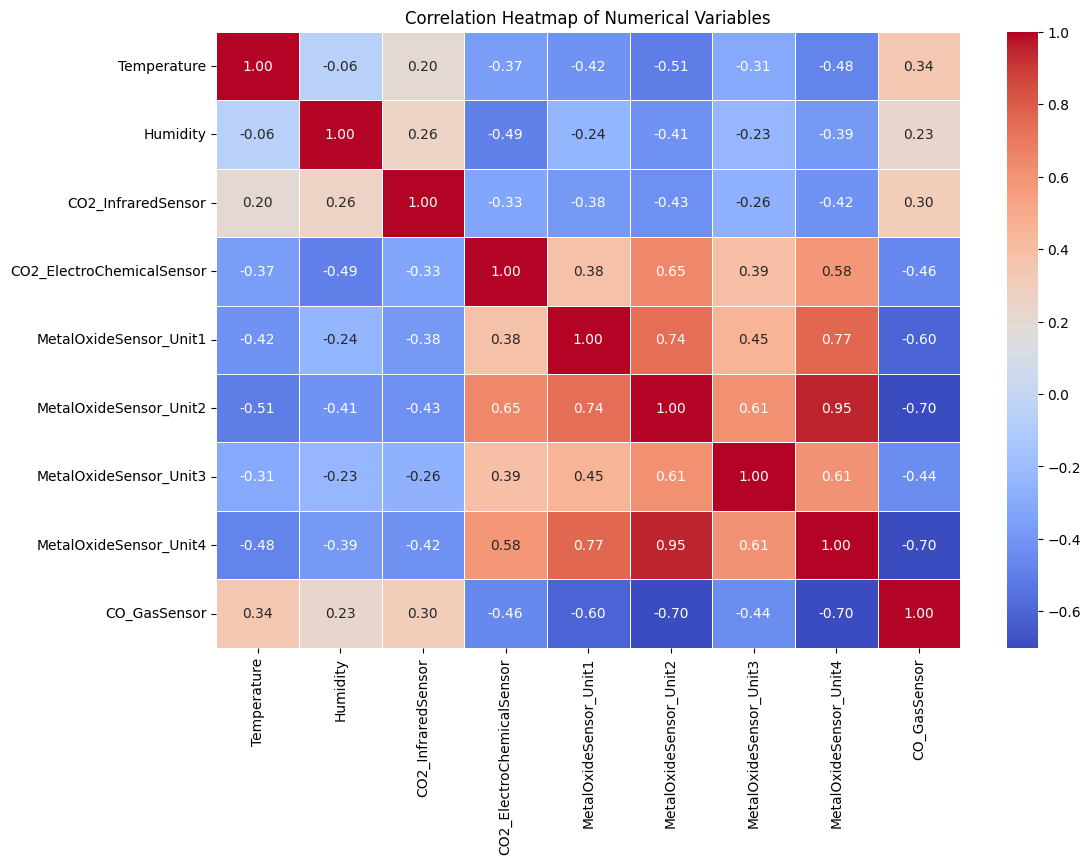

In [61]:
# =========================
# CORRELATION MATRIX FOR NUMERICAL COLUMNS
# =========================

# Remove SESSION_ID if it exists
df_corr = df.drop(columns=['Session ID'], errors='ignore')

# Select only numerical columns
numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_df.corr()

# Display correlation matrix
print("Correlation Matrix:")
display(corr_matrix)

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

We removed Session ID eventhough it is a numerical variable as it acts as an identifier and does not contribute to meaningful insights during data analysis.

Insights:
- CO2_ElectroChemicalSensor, MetalOxideSensor_Unit1, MetalOxideSensor_Unit2, MetalOxideSensor_Unit3, MetalOxideSensor_Unit4 have moderate to high correalation to eachother as compared to other columsn in the dataset. 
- We used this correlation matrix as a guide to fill in the null values in the columns. 
- CO_GasSensor has a negative correlation to all the Sensors except for CO2_InfraredSensor, this means that when 

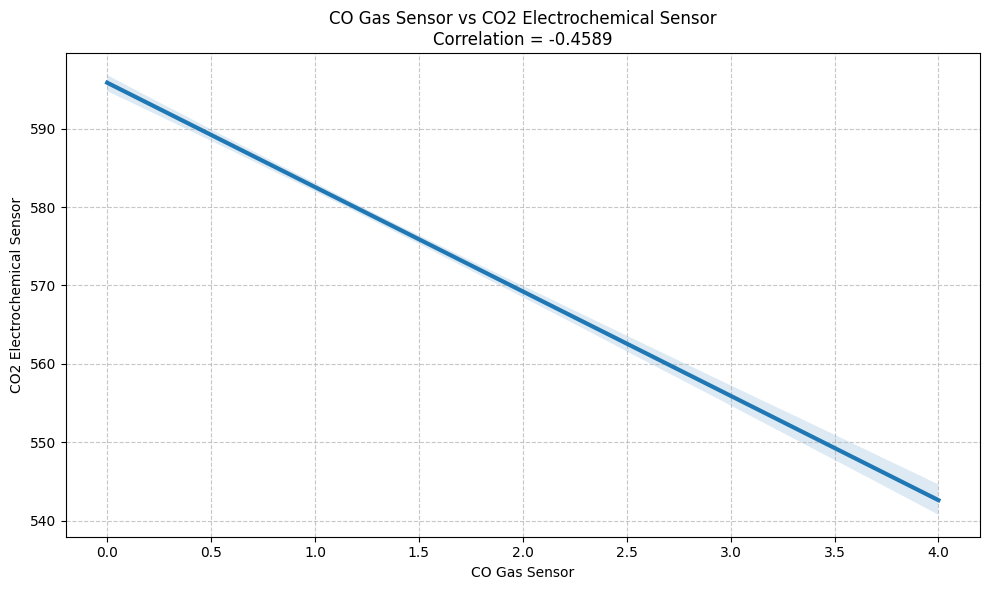

In [62]:
   
corr = df['CO_GasSensor'].corr(df['CO2_ElectroChemicalSensor'])

plt.figure(figsize=(10, 6))

sns.regplot(
    x='CO_GasSensor',
    y='CO2_ElectroChemicalSensor',
    data=df,
    scatter=False,   # hides dots
    line_kws={'linewidth': 3}
)

plt.title(
    f'CO Gas Sensor vs CO2 Electrochemical Sensor\nCorrelation = {corr:.4f}'
)

plt.xlabel('CO Gas Sensor')
plt.ylabel('CO2 Electrochemical Sensor')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

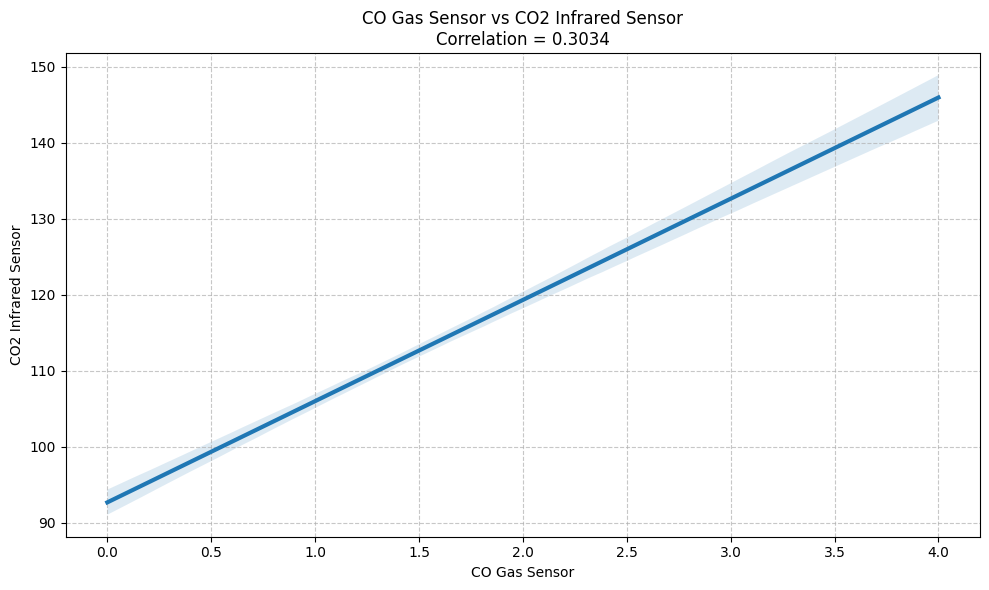

In [63]:
corr = df['CO_GasSensor'].corr(df['CO2_InfraredSensor'])

plt.figure(figsize=(10, 6))

sns.regplot(
    x='CO_GasSensor',
    y='CO2_InfraredSensor',
    data=df,
    scatter=False,   # hides dots
    line_kws={'linewidth': 3}
)

plt.title(
    f'CO Gas Sensor vs CO2 Infrared Sensor\nCorrelation = {corr:.4f}'
)

plt.xlabel('CO Gas Sensor')
plt.ylabel('CO2 Infrared Sensor')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [64]:
# =========================
# SHOW THE PERCENTAGE OF MISSING VALUES IN EACH COLUMN
# =========================

missing_percentages = (df.isnull().sum() / len(df)) * 100
print("Percentage of Missing Values in Each Column:")
print(missing_percentages)

Percentage of Missing Values in Each Column:
Time of Day                   0.000000
Temperature                   0.000000
Humidity                      0.000000
CO2_InfraredSensor            0.000000
CO2_ElectroChemicalSensor     0.000000
MetalOxideSensor_Unit1        0.000000
MetalOxideSensor_Unit2       14.344443
MetalOxideSensor_Unit3        0.000000
MetalOxideSensor_Unit4        0.000000
CO_GasSensor                  8.515636
Session ID                    0.000000
HVAC Operation Mode           0.000000
Ambient Light Level          11.040963
Activity Level                0.000000
dtype: float64


This shows that there are missing values in Humidity, MetalOxideSensor_Unit2, CO_GasSensor and Ambient Light Level. It is not a viable solution to remove all the rows that contain missing values as that causes a huge valuable data loss. So we decided to sub in values based on the correlation of other columns, median of the column or mode of the column. 

In [65]:
# =========================
# HUMIDITY - FILL MISSING VALUES
# =========================
# Since missing percentage is below 30%
# and correlation shows weak/no strong relationship,
# use median.

humidity_median = df["Humidity"].median()

df["Humidity"] = df["Humidity"].fillna(humidity_median)

print("Humidity missing values filled using median.")
print("Median used:", round(humidity_median, 2))
print("Remaining missing Humidity values:", df["Humidity"].isnull().sum())

Humidity missing values filled using median.
Median used: 51.42
Remaining missing Humidity values: 0


The missing percentage of the values in humidity column is below 20% and it shows that it has weak correlation between the columns, so we decided to use median to substitute into the missing values. Median is a good value to sub into the null values as it is resistant to the influence of outliers and better represents the central tendency of skewed data. So median imputation is the most robust and appropriate approach.

In [66]:
# =========================
# METAL OXIDE SENSOR UNIT 2 - FILL MISSING VALUES
# =========================
# Method: Take average of the other 3 metal oxide sensors
# for rows where Unit2 is missing.

df["MetalOxideSensor_Unit2"] = df["MetalOxideSensor_Unit2"].fillna(
    df[
        [
            "MetalOxideSensor_Unit1",
            "MetalOxideSensor_Unit3",
            "MetalOxideSensor_Unit4"
        ]
    ].mean(axis=1)
)

print("MetalOxideSensor_Unit2 missing values filled using average of Unit1, Unit3, and Unit4.")
print("Remaining missing MetalOxideSensor_Unit2 values:", df["MetalOxideSensor_Unit2"].isnull().sum())

MetalOxideSensor_Unit2 missing values filled using average of Unit1, Unit3, and Unit4.
Remaining missing MetalOxideSensor_Unit2 values: 0


The missing values in MetalOxideSensor_Unit2 were replaced using the average of metaloxidesensor Unit 1, 3 and 4. We chose this approach as all 4 metal oxide sensors have moderate to high correlation to eachother as they measure the similar environmental conditions. Compared to using a global statistic such as mean or median of Unit2 column, we felt that averaging the temperatues of unit 1, 3 and 4 for the specific row and input to the that specific row of null value in unit 2 is a better approach. This allows the imputed value to better reflect the actual conditions present at the time of measurement, resulting in more accurate and representative estimate of the missing value. 

In [67]:
# =========================
# CO_GASSENSOR - FILL MISSING VALUES
# =========================
# CO_GasSensor only has values from 1 to 4.
# This means it is a category/level, not a continuous value.
# Therefore, use mode.

co_mode = df["CO_GasSensor"].mode()[0]

df["CO_GasSensor"] = df["CO_GasSensor"].fillna(co_mode)

print("CO_GasSensor missing values filled using mode.")
print("Mode used:", co_mode)
print("Remaining missing CO_GasSensor values:", df["CO_GasSensor"].isnull().sum())

CO_GasSensor missing values filled using mode.
Mode used: 1.0
Remaining missing CO_GasSensor values: 0


Missing values in the CO_Sensor column were imputed using the mode of the variable. The CO_GasSensor featuer consists of a limited set of discrete sensor levels ranging from 1-4, indicating that it behaves as an ordinal categorical variable rather than a continuous numerical measurement. Since mean or median imputation could produce values that do not correspond to valid sensor levels, mode imputation was selected. The mode represents the most frequently occurring sensor level and preserves both the validity and distribution of the original data, making it an appropriate method for handling missing values in this feature.

In [68]:
# =========================
# AMBIENT LIGHT LEVEL - MODE BY TIME OF DAY
# =========================
# Find the most common Ambient Light Level for each Time of Day

ambient_mode_by_time = df.groupby("Time of Day")["Ambient Light Level"].agg(
    lambda x: x.mode()[0] if not x.mode().empty else pd.NA
)

print("Mode of Ambient Light Level by Time of Day:")
display(ambient_mode_by_time)

Mode of Ambient Light Level by Time of Day:


Time of Day
afternoon    very bright
evening      very bright
morning      very bright
night        very bright
Name: Ambient Light Level, dtype: str

In [69]:

# =========================
# AMBIENT LIGHT LEVEL - FILL MISSING VALUES
# =========================
# Fill missing Ambient Light Level using the mode for that specific Time of Day

df["Ambient Light Level"] = df["Ambient Light Level"].fillna(
    df["Time of Day"].map(ambient_mode_by_time)
)

# If any missing values still remain, fill with overall mode
overall_ambient_mode = df["Ambient Light Level"].mode()[0]

df["Ambient Light Level"] = df["Ambient Light Level"].fillna(overall_ambient_mode)

print("Ambient Light Level missing values filled using mode based on Time of Day.")
print("Overall mode used as backup:", overall_ambient_mode)
print("Remaining missing Ambient Light Level values:", df["Ambient Light Level"].isnull().sum())

Ambient Light Level missing values filled using mode based on Time of Day.
Overall mode used as backup: very bright
Remaining missing Ambient Light Level values: 0


In [70]:
# =========================
# FORMAT DECIMAL VALUES TO 2 DECIMAL PLACES
# =========================

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols] = df[numeric_cols].round(2)

print("Decimal values rounded to 2 decimal places.")

Decimal values rounded to 2 decimal places.


In [71]:
# =========================
# FORMAT COLUMN NAMES
# =========================
# For column names:
# - all caps
# - replace spaces with underscores

df.columns = (
    df.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_", regex=False)
)

print("Column names formatted:")
print(df.columns.tolist())

Column names formatted:
['TIME_OF_DAY', 'TEMPERATURE', 'HUMIDITY', 'CO2_INFRAREDSENSOR', 'CO2_ELECTROCHEMICALSENSOR', 'METALOXIDESENSOR_UNIT1', 'METALOXIDESENSOR_UNIT2', 'METALOXIDESENSOR_UNIT3', 'METALOXIDESENSOR_UNIT4', 'CO_GASSENSOR', 'SESSION_ID', 'HVAC_OPERATION_MODE', 'AMBIENT_LIGHT_LEVEL', 'ACTIVITY_LEVEL']


In [72]:
df.shape

(6811, 14)

In [73]:
# =========================
# SAVE CLEANED DATASET
# =========================

df.to_csv("cleaned_gas_monitoring.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [29]:
# =========================
# SAVE CLEANED DATASET IN VS CODE
# =========================

df.to_csv("cleaned_gas_monitoring.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
